<a href="https://colab.research.google.com/github/Sudarshan0851/python_notes_by_sudarshan/blob/main/Data_Visualisation_assignment_sudarshan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Topic: Data Visualization + Data Cleaning + NumPy Operations**



import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

# Load inbuilt dataset

df = sns.load_dataset("titanic")

df.head()

Q1. Display first 10 rows and dataset info.


Task:

Show first 10 rows

Print dataset shape

Show missing values

Intuition:

 observe:

Missing values in age, deck, embark_town

Mixture of categorical and numerical columns

Around 891 rows

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Show first 10 rows
df = sns.load_dataset("titanic")
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [ ]:
# Print dataset shape
df.shape

(891, 15)

In [ ]:
# Show missing values
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Missing values in age, deck, embark_town
df[['age','deck','embark_town']].isnull()

,age,deck,embark_town
0,False,True,False
1,False,False,False
2,False,True,False
3,False,False,False
4,False,True,False
...,...,...,...
886,False,True,False
887,False,False,False
888,True,True,False
889,False,False,False


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Q2.Find survival rate percentage.

Intuition:
Value will be around 38%.

This tells survival was difficult — class & gender might influence survival

In [ ]:
(df['survived'].sum() / df.shape[0]) * 100


np.float64(38.38383838383838)

Q3. Fill missing Age values with mean.


Intuition:
Age is important numerical feature. Replacing with mean keeps distribution stable.

In [ ]:
df['age']

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [ ]:
df['age'] = df['age'].fillna(df['age'].mean())

In [ ]:
df['age']

,age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [ ]:
df['age'].isnull().sum()

np.int64(0)

Q4. Drop column with too many missing values.

Intuition:

deck has too many missing values → not reliable for analysis.

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [ ]:
df['deck'].isnull().sum()

np.int64(688)

In [ ]:
df.dropna(axis=1,thresh=300)
# deck is removed because it having most of null valuse (688)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


Q5. Convert categorical column to numerical using NumPy.

Convert sex column:

male → 1

female → 0


Intuition:

Machine learning models need numerical data.

In [ ]:
df['sex'] = np.where(df['sex'] == 'male', 1, 0)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,0,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,0,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,1,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


Q6. Create new feature using NumPy.

Create family_size = sibsp + parch

Intuition:
Passengers traveling with family might have better survival chances.

In [ ]:
df['parch']

,parch
0,0
1,0
2,0
3,0
4,0
...,...
886,0
887,0
888,2
889,0


In [ ]:
df['family_size'] = df['sibsp'] + df['parch']


In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,1,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,0,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,0,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,0,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,1,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,0
887,1,1,0,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,0
888,0,3,0,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,3
889,1,1,1,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,0


Q7. Line Plot – Survival rate by Passenger Class

Intuition:

1st class passengers had higher survival.

Shows social-economic impact.

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


In [ ]:
survival_rate = df.groupby('class')['survived'].mean()*100
survival_rate.sort_index(ascending=False, inplace=True)
survival_rate



/tmp/ipykernel_6831/637427482.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby('class')['survived'].mean()*100


,survived
class,
Third,24.236253
Second,47.282609
First,62.962963


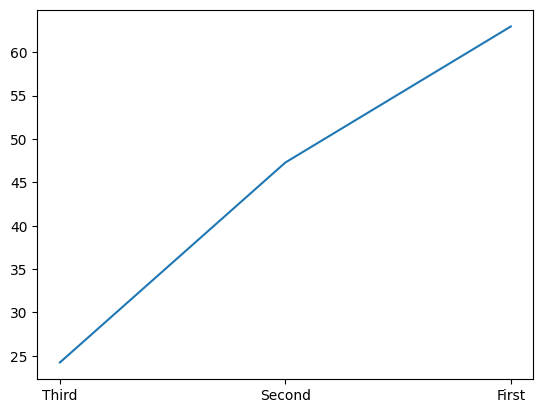

In [ ]:
plt.plot(survival_rate.index,survival_rate.values)

Q8. Scatter Plot – Age vs Fare

Intuition:

Higher fare passengers more likely survived.

Age does not strongly correlate with fare.

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


<Axes: xlabel='age', ylabel='fare'>

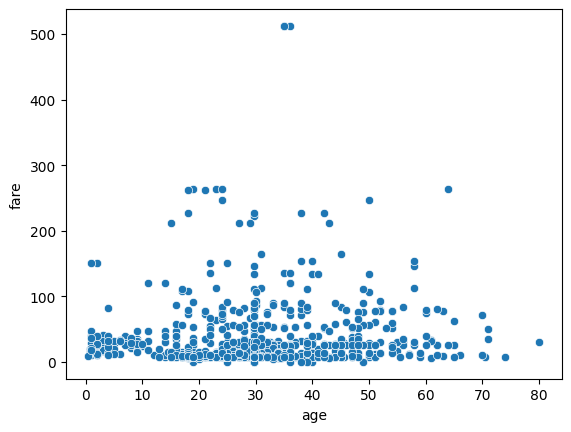

In [ ]:
import seaborn as sns
sns.scatterplot(data=df,x='age',y='fare')

Q9. Boxplot – Age Distribution by Survival

Intuition:

Children had higher survival rate.

Outliers present in older ages.

<Axes: xlabel='survived', ylabel='age'>

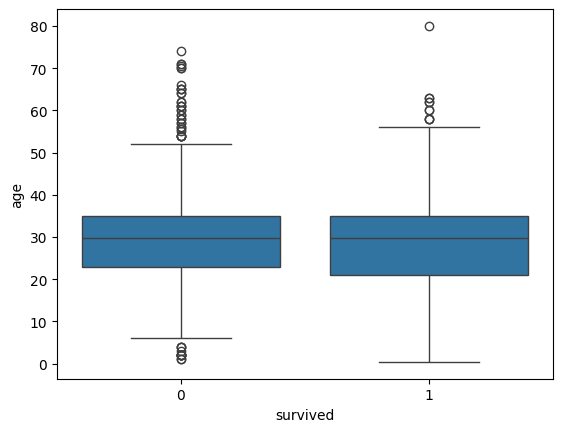

In [ ]:
sns.boxplot(data=df,x='survived',y='age')

Q10. Histplot – Age Distribution

Intuition:

Most passengers between 20–40.

Slight right skew.

<Axes: xlabel='age', ylabel='Count'>

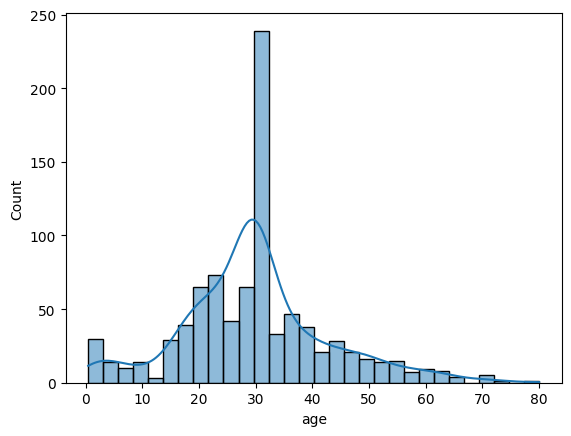

In [ ]:
sns.histplot(data=df,x='age',bins=30, kde=True)

Q11. Displot – Fare Distribution

Intuition:

Highly right-skewed.

Few passengers paid very high fares.

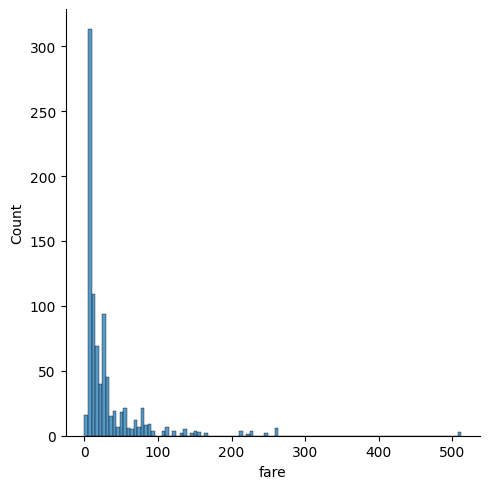

In [ ]:
sns.displot(data=df,x='fare')

Q12. Catplot – Survival by Gender

Intuition:

Females had much higher survival rate.

Strong gender impact.

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'family_size', 'age_category'],
      dtype='object')

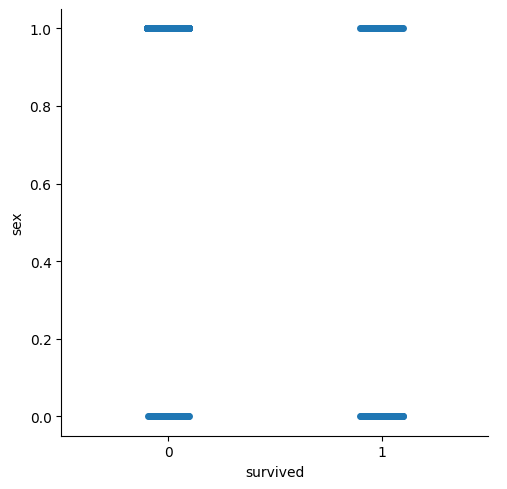

In [ ]:
sns.catplot(data=df,x='survived',y='sex')

Q13. Find average fare using NumPy.



In [ ]:
import numpy as np
np.mean(df['fare'])

np.float64(32.204207968574636)

Q14. Find standard deviation of age.

In [ ]:
np.std(df['age'])

12.994716872789033

Q15. Create Age Category using NumPy.

If age < 18 → Child

Else → Adult

Intuition:
Measures age spread

In [ ]:
df["age_category"] = np.where(df["age"] < 18, "Child", "Adult")

In [ ]:
df['age_category'].unique()

array(['Adult', 'Child'], dtype=object)

Interpretation Based Questions (Critical Thinking)


Why did 1st class passengers survive more?

Why is fare distribution right-skewed?

Is age strongly affecting survival?

Why convert categorical data into numerical?

What happens if we don’t clean missing values?